(parallel)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# NumPy در مقابل Numba در مقابل JAX

در سخنرانی‌های قبلی، سه کتابخانه اصلی برای محاسبات علمی و عددی را بحث کردیم:

* [NumPy](numpy)
* [Numba](numba)
* [JAX](jax_intro)

کدام یک را باید در هر موقعیت استفاده کنیم؟

این سخنرانی به آن سؤال پاسخ می‌دهد، حداقل تا حدی، با بحث در مورد برخی موارد استفاده.

قبل از شروع، توجه می‌کنیم که دو مورد اول یک جفت طبیعی هستند: NumPy و Numba به خوبی با هم کار می‌کنند.

JAX، از سوی دیگر، به تنهایی می‌ایستد.

هنگام بررسی هر رویکرد، نه تنها کارایی و رد پای حافظه، بلکه وضوح و سهولت استفاده را نیز در نظر خواهیم گرفت.

علاوه بر آنچه در Anaconda موجود است، این سخنرانی به کتابخانه‌های زیر نیاز دارد:

In [1]:
!pip install quantecon jax

```{include} _admonition/gpu.md
```

ما از import های زیر استفاده خواهیم کرد.

In [2]:
import random
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm
import jax
import jax.numpy as jnp

## عملیات برداری شده

برخی عملیات را می‌توان به طور کامل برداری کرد --- تمام حلقه‌ها به راحتی حذف می‌شوند و عملیات عددی به محاسبات روی آرایه‌ها تقلیل می‌یابند.

در این حالت، کدام رویکرد بهترین است؟

### بیان مسئله

مسئله بیشینه‌سازی تابع $f$ از دو متغیر $(x,y)$ روی مربع $[-a, a] \times [-a, a]$ را در نظر بگیرید.

برای $f$ و $a$ بیایید انتخاب کنیم

$$
f(x,y) = \frac{\cos(x^2 + y^2)}{1 + x^2 + y^2}
\quad \text{و} \quad
a = 3
$$

در اینجا نمودار $f$ آمده است

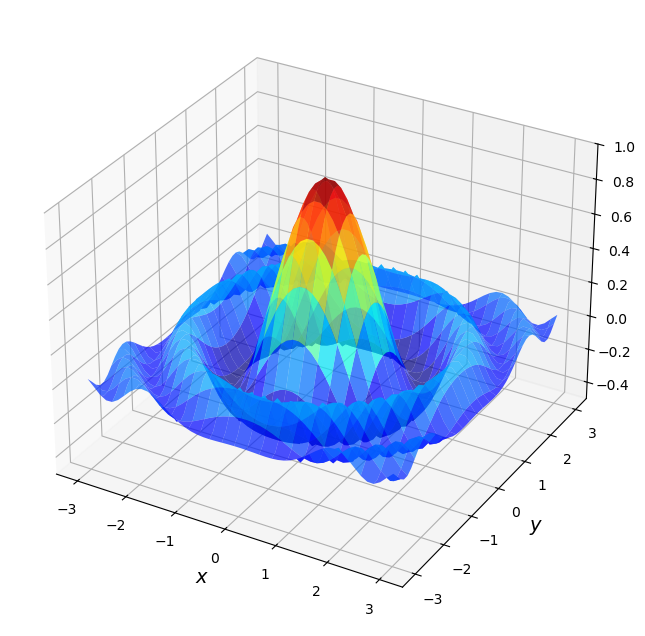

In [3]:
def f(x, y):
    return np.cos(x**2 + y**2) / (1 + x**2 + y**2)

xgrid = np.linspace(-3, 3, 50)
ygrid = xgrid
x, y = np.meshgrid(xgrid, ygrid)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x,
                y,
                f(x, y),
                rstride=2, cstride=2,
                cmap=cm.jet,
                alpha=0.7,
                linewidth=0.25)
ax.set_zlim(-0.5, 1.0)
ax.set_xlabel('$x$', fontsize=14)
ax.set_ylabel('$y$', fontsize=14)
plt.show()

به خاطر این تمرین، ما از روش brute force برای بیشینه‌سازی استفاده خواهیم کرد.

1. $f$ را برای تمام $(x,y)$ در یک شبکه روی مربع ارزیابی کنید.
1. حداکثر مقادیر مشاهده شده را برگردانید.

فقط برای نشان دادن ایده، در اینجا یک نسخه غیر برداری شده است که از حلقه‌های Python استفاده می‌کند.

In [4]:
grid = np.linspace(-3, 3, 50)
m = -np.inf
for x in grid:
    for y in grid:
        z = f(x, y)
        if z > m:
            m = z

### برداری‌سازی NumPy

اگر به برداری‌سازی به سبک NumPy تغییر دهیم، می‌توانیم از یک شبکه بسیار بزرگتر استفاده کنیم و کد نسبتاً سریع اجرا می‌شود.

در اینجا از `np.meshgrid` برای ایجاد شبکه‌های ورودی دوبعدی `x` و `y` استفاده می‌کنیم به گونه‌ای که `f(x, y)` تمام ارزیابی‌ها را روی شبکه حاصلضرب تولید می‌کند.

(این استراتژی به Matlab بازمی‌گردد.)

In [5]:
grid = np.linspace(-3, 3, 3_000)
x, y = np.meshgrid(grid, grid)

with qe.Timer(precision=8):
    z_max_numpy = np.max(f(x, y))

print(f"NumPy result: {z_max_numpy:.6f}")

0.15403843 seconds elapsed
NumPy result: 0.999998


در نسخه برداری شده، تمام حلقه‌ها در کد کامپایل شده انجام می‌شوند.

علاوه بر این، NumPy از چندنخی ضمنی استفاده می‌کند، به طوری که حداقل مقداری موازی‌سازی رخ می‌دهد.

(موازی‌سازی نمی‌تواند بسیار کارآمد باشد زیرا فایل باینری قبل از اینکه اندازه آرایه‌های `x` و `y` را ببیند کامپایل می‌شود.)


### مقایسه با Numba

حالا بیایید ببینیم آیا می‌توانیم با استفاده از Numba با یک حلقه ساده به عملکرد بهتری دست یابیم.

In [6]:
import numba

@numba.jit
def compute_max_numba(grid):
    m = -np.inf
    for x in grid:
        for y in grid:
            z = np.cos(x**2 + y**2) / (1 + x**2 + y**2)
            if z > m:
                m = z
    return m

grid = np.linspace(-3, 3, 3_000)

with qe.Timer(precision=8):
    z_max_numpy = compute_max_numba(grid)

print(f"Numba result: {z_max_numpy:.6f}")

0.23172164 seconds elapsed
Numba result: 0.999998


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود.

In [7]:
with qe.Timer(precision=8):
    compute_max_numba(grid)

0.10740042 seconds elapsed


بسته به دستگاه شما، نسخه Numba می‌تواند کمی کندتر یا کمی سریعتر از NumPy باشد.

از یک طرف، NumPy محاسبات کارآمد (مانند Numba) را با مقداری چندنخی (برخلاف این کد Numba) ترکیب می‌کند که مزیتی فراهم می‌کند.

از طرف دیگر، روال Numba از حافظه بسیار کمتری استفاده می‌کند، زیرا ما فقط با یک شبکه یک‌بعدی کار می‌کنیم.


### Numba موازی شده

حالا بیایید موازی‌سازی با Numba را با استفاده از `prange` امتحان کنیم:

در اینجا یک تلاش ساده و *نادرست* آمده است.

In [8]:
@numba.jit(parallel=True)
def compute_max_numba_parallel(grid):
    n = len(grid)
    m = -np.inf
    for i in numba.prange(n):
        for j in range(n):
            x = grid[i]
            y = grid[j]
            z = np.cos(x**2 + y**2) / (1 + x**2 + y**2)
            if z > m:
                m = z
    return m


معمولاً این نتیجه نادرستی برمی‌گرداند:

In [9]:
z_max_parallel_incorrect = compute_max_numba_parallel(grid)
print(f"Numba result: {z_max_parallel_incorrect} 😱")

Numba result: -inf 😱


دلیل این است که متغیر `m` بین نخ‌ها مشترک است و به درستی کنترل نمی‌شود.

وقتی چندین نخ سعی می‌کنند همزمان `m` را بخوانند و بنویسند، با یکدیگر تداخل می‌کنند.

نخ‌ها مقادیر قدیمی `m` را می‌خوانند یا به‌روزرسانی‌های یکدیگر را بازنویسی می‌کنند --- یا `m` هرگز از مقدار اولیه خود به‌روزرسانی نمی‌شود.

در اینجا یک نسخه با دقت بیشتری نوشته شده است.

In [10]:
@numba.jit(parallel=True)
def compute_max_numba_parallel(grid):
    n = len(grid)
    row_maxes = np.empty(n)
    for i in numba.prange(n):
        row_max = -np.inf
        for j in range(n):
            x = grid[i]
            y = grid[j]
            z = np.cos(x**2 + y**2) / (1 + x**2 + y**2)
            if z > row_max:
                row_max = z
        row_maxes[i] = row_max
    return np.max(row_maxes)

اکنون بلوک کدی که `for i in numba.prange(n)` روی آن عمل می‌کند بین `i` ها مستقل است.

هر نخ به یک عنصر جداگانه از آرایه `row_maxes` می‌نویسد و موازی‌سازی ایمن است.

In [11]:
z_max_parallel = compute_max_numba_parallel(grid)
print(f"Numba result: {z_max_parallel:.6f}")

Numba result: 0.999998


در اینجا زمان‌بندی آمده است.

In [12]:
with qe.Timer(precision=8):
    compute_max_numba_parallel(grid)

0.04463077 seconds elapsed


اگر چندین هسته دارید، باید حداقل برخی مزایا را از موازی‌سازی در اینجا ببینید.

برای دستگاه‌های قدرتمندتر و اندازه‌های شبکه بزرگتر، موازی‌سازی می‌تواند افزایش سرعت قابل توجهی ایجاد کند، حتی روی CPU.


### کد برداری شده با JAX

در ظاهر، کد برداری شده در JAX شبیه به کد NumPy است.

اما تفاوت‌هایی نیز وجود دارد که در اینجا آنها را برجسته می‌کنیم.

بیایید با تابع شروع کنیم.

In [13]:
@jax.jit
def f(x, y):
    return jnp.cos(x**2 + y**2) / (1 + x**2 + y**2)


همانند NumPy، برای به دست آوردن شکل درست و محاسبه حلقه `for` تودرتوی صحیح، می‌توانیم از عملیات `meshgrid` طراحی شده برای این منظور استفاده کنیم:

In [14]:
grid = jnp.linspace(-3, 3, 3_000)
x_mesh, y_mesh = np.meshgrid(grid, grid)

with qe.Timer(precision=8):
    z_max = jnp.max(f(x_mesh, y_mesh))
    z_max.block_until_ready()

print(f"Plain vanilla JAX result: {z_max:.6f}")

0.08639002 seconds elapsed
Plain vanilla JAX result: 0.999998


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود.

In [15]:
with qe.Timer(precision=8):
    z_max = jnp.max(f(x_mesh, y_mesh))
    z_max.block_until_ready()

0.03524017 seconds elapsed


پس از کامپایل، JAX به دلیل شتاب GPU به طور قابل توجهی سریعتر از NumPy است.

سربار کامپایل یک هزینه یک‌بار مصرف است که زمانی که تابع به طور مکرر فراخوانی می‌شود، بازگشت سرمایه دارد.


### JAX به علاوه vmap

یک مشکل با کد NumPy و کد JAX وجود دارد:

در حالی که آرایه‌های تخت حافظه کمی دارند

In [16]:
grid.nbytes 

12000

شبکه‌های mesh فشرده از نظر حافظه هستند

In [17]:
x_mesh.nbytes + y_mesh.nbytes

72000000

این استفاده اضافی از حافظه می‌تواند یک مشکل بزرگ در محاسبات تحقیقاتی واقعی باشد.

خوشبختانه، JAX رویکرد متفاوتی را با استفاده از [jax.vmap](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html) می‌پذیرد.

#### نسخه 1

در اینجا یک راه برای اعمال `vmap` آمده است.

In [18]:
# f را تنظیم کنید تا f(x, y) را در هر x برای هر y داده شده محاسبه کند
f_vec_x = lambda y: f(grid, y)
# یک تابع دوم ایجاد کنید که این عملیات را روی تمام y برداری کند
f_vec = jax.vmap(f_vec_x)

اکنون `f_vec` هنگام فراخوانی با آرایه تخت `grid`، `f(x,y)` را در هر `x,y` محاسبه می‌کند.

بیایید زمان‌بندی را ببینیم:

In [19]:
with qe.Timer(precision=8):
    z_max = jnp.max(f_vec(grid))
    z_max.block_until_ready()

print(f"JAX vmap v1 result: {z_max:.6f}")

0.06368899 seconds elapsed
JAX vmap v1 result: 0.999998


In [20]:
with qe.Timer(precision=8):
    z_max = jnp.max(f_vec(grid))
    z_max.block_until_ready()

0.02929759 seconds elapsed


با اجتناب از آرایه‌های ورودی بزرگ `x_mesh` و `y_mesh`، این نسخه `vmap` از حافظه بسیار کمتری استفاده می‌کند.

وقتی روی CPU اجرا می‌شود، زمان اجرای آن شبیه به نسخه meshgrid است.

وقتی روی GPU اجرا می‌شود، معمولاً به طور قابل توجهی سریعتر است.

در واقع، استفاده از `vmap` مزیت دیگری دارد: به ما اجازه می‌دهد برداری‌سازی را به مراحل تقسیم کنیم.

این منجر به کدی می‌شود که اغلب راحت‌تر از کد برداری شده سنتی قابل درک است.

ما این ایده‌ها را بیشتر هنگام حل مسائل بزرگتر بررسی خواهیم کرد.


### نسخه 2 vmap

می‌توانیم با استفاده از vmap همچنان کارآمدتر از نظر حافظه باشیم.

در حالی که در نسخه قبلی از آرایه‌های ورودی بزرگ اجتناب می‌کنیم، هنوز آرایه خروجی بزرگ `f(x,y)` را قبل از محاسبه حداکثر ایجاد می‌کنیم.

بیایید یک رویکرد کمی متفاوت را امتحان کنیم که max را به داخل می‌برد.

به دلیل این تغییر، ما هرگز آرایه دوبعدی `f(x,y)` را محاسبه نمی‌کنیم.

In [21]:
@jax.jit
def compute_max_vmap_v2(grid):
    # یک تابع بسازید که حداکثر را در امتداد هر سطر بگیرد
    f_vec_x_max = lambda y: jnp.max(f(grid, y))
    # تابع را برداری کنید تا بتوانیم روی تمام سطرها همزمان فراخوانی کنیم
    f_vec_max = jax.vmap(f_vec_x_max)
    # تابع برداری شده را فراخوانی کنید و حداکثر را بگیرید
    return jnp.max(f_vec_max(grid))

در اینجا

* `f_vec_x_max` حداکثر را در امتداد هر سطر داده شده محاسبه می‌کند
* `f_vec_max` یک نسخه برداری شده است که می‌تواند حداکثر تمام سطرها را به صورت موازی محاسبه کند.

ما این تابع را روی تمام سطرها اعمال می‌کنیم و سپس حداکثر max های سطر را می‌گیریم.

بیایید آن را امتحان کنیم.

In [22]:
with qe.Timer(precision=8):
    z_max = compute_max_vmap_v2(grid).block_until_ready()

print(f"JAX vmap v1 result: {z_max:.6f}")

0.06610608 seconds elapsed
JAX vmap v1 result: 0.999998


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود:

In [23]:
with qe.Timer(precision=8):
    z_max = compute_max_vmap_v2(grid).block_until_ready()

0.02745748 seconds elapsed


اگر این را روی GPU اجرا می‌کنید، همانطور که ما این کار را می‌کنیم، باید افزایش سرعت قابل توجه دیگری را ببینید.


### خلاصه

به نظر ما، JAX برنده برای عملیات برداری شده است.

هم از نظر سرعت (از طریق JIT-compilation و موازی‌سازی) و هم از نظر کارایی حافظه (از طریق vmap) بر NumPy غلبه می‌کند.

علاوه بر این، رویکرد `vmap` گاهی اوقات می‌تواند منجر به کد به طور قابل توجهی واضح‌تری شود.

در حالی که Numba چشمگیر است، زیبایی JAX این است که با عملیات کاملاً برداری شده، می‌توانیم دقیقاً همان کد را روی دستگاه‌های با شتاب‌دهنده سخت‌افزاری اجرا کنیم و بدون تلاش اضافی از تمام مزایا بهره‌مند شویم.

علاوه بر این، JAX قبلاً می‌داند چگونه بسیاری از عملیات آرایه رایج را به طور مؤثر موازی کند، که کلید اجرای سریع است.

برای اکثر موارد مواجه شده در اقتصاد، اقتصادسنجی و امور مالی، بسیار بهتر است که برای موازی‌سازی کارآمد به کامپایلر JAX تحویل دهیم تا اینکه سعی کنیم این روال‌ها را خودمان کدنویسی دستی کنیم.


## عملیات ترتیبی

برخی عملیات ذاتاً ترتیبی هستند -- و از این رو برداری کردن آنها دشوار یا غیرممکن است.

در این حالت NumPy گزینه ضعیفی است و ما با انتخاب Numba یا JAX باقی می‌مانیم.

برای مقایسه این انتخاب‌ها، مسئله تکرار روی نقشه درجه دوم را که در {doc}`سخنرانی Numba <numba>` خود دیدیم، دوباره بررسی خواهیم کرد.


### نسخه Numba

در اینجا نسخه Numba آمده است.

In [24]:
@numba.jit
def qm(x0, n, α=4.0):
    x = np.empty(n+1)
    x[0] = x0
    for t in range(n):
      x[t+1] = α * x[t] * (1 - x[t])
    return x

بیایید یک سری زمانی به طول 10,000,000 تولید کنیم و اجرا را زمان‌بندی کنیم:

In [25]:
n = 10_000_000

with qe.Timer(precision=8):
    x = qm(0.1, n)

0.10004187 seconds elapsed


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود:

In [26]:
with qe.Timer(precision=8):
    x = qm(0.1, n)

0.02444673 seconds elapsed


Numba این عملیات ترتیبی را به طور بسیار کارآمد مدیریت می‌کند.

توجه کنید که اجرای دوم پس از تکمیل کامپایل JIT به طور قابل توجهی سریعتر است.

کامپایل Numba معمولاً بسیار سریع است و عملکرد کد حاصل برای عملیات ترتیبی مانند این عالی است.

### نسخه JAX

حالا بیایید یک نسخه JAX با استفاده از `lax.scan` ایجاد کنیم:

(ما `n` را ایستا نگه می‌داریم زیرا بر اندازه آرایه تأثیر می‌گذارد و از این رو JAX می‌خواهد روی مقدار آن در کد کامپایل شده تخصصی شود.)

In [27]:
from jax import lax
from functools import partial

cpu = jax.devices("cpu")[0]

@partial(jax.jit, static_argnums=(1,), device=cpu)
def qm_jax(x0, n, α=4.0):
    def update(x, t):
        x_new = α * x * (1 - x)
        return x_new, x_new

    _, x = lax.scan(update, x0, jnp.arange(n))
    return jnp.concatenate([jnp.array([x0]), x])

این کد خواندن آسانی ندارد اما، در اصل، `lax.scan` به طور مکرر `update` را فراخوانی می‌کند و بازگشت‌های `x_new` را در یک آرایه جمع می‌کند.

```{note}
خوانندگان تیزبین متوجه خواهند شد که ما `device=cpu` را در decorator `jax.jit` مشخص می‌کنیم.

محاسبه از بسیاری عملیات ترتیبی کوچک تشکیل شده است که فرصت کمی برای بهره‌برداری GPU از موازی‌سازی باقی می‌گذارد.

در نتیجه، سربار راه‌اندازی kernel تمایل دارد روی GPU غالب شود و CPU را متناسب‌تر برای این بار کاری می‌کند.

خوانندگان کنجکاو می‌توانند حذف این گزینه را امتحان کنند تا ببینند چگونه عملکرد تغییر می‌کند.
```

بیایید آن را با همان پارامترها زمان‌بندی کنیم:

In [28]:
with qe.Timer(precision=8):
    x_jax = qm_jax(0.1, n).block_until_ready()

0.10270309 seconds elapsed


بیایید دوباره اجرا کنیم تا سربار کامپایل حذف شود:

In [29]:
with qe.Timer(precision=8):
    x_jax = qm_jax(0.1, n).block_until_ready()

0.05579925 seconds elapsed


JAX نیز برای این عملیات ترتیبی کاملاً کارآمد است.

هم JAX و هم Numba عملکرد قوی پس از کامپایل ارائه می‌دهند، با این که Numba معمولاً (اما نه همیشه) سرعت‌های کمی بهتری در عملیات کاملاً ترتیبی ارائه می‌دهد.


### خلاصه

در حالی که هم Numba و هم JAX عملکرد قوی برای عملیات ترتیبی ارائه می‌دهند، *تفاوت‌های قابل توجهی در خوانایی کد و سهولت استفاده وجود دارد*.

نسخه Numba ساده و طبیعی برای خواندن است: ما به سادگی یک آرایه اختصاص می‌دهیم و آن را عنصر به عنصر با استفاده از یک حلقه استاندارد Python پر می‌کنیم.

این دقیقاً نحوه تفکر اکثر برنامه‌نویسان در مورد الگوریتم است.

نسخه JAX، از سوی دیگر، نیاز به استفاده از `lax.scan` دارد که به طور قابل توجهی کمتر شهودی است.

علاوه بر این، آرایه‌های تغییرناپذیر JAX به این معنی است که نمی‌توانیم به سادگی عناصر آرایه را در جا به‌روزرسانی کنیم و تکرار مستقیم الگوریتم مورد استفاده توسط Numba را سخت می‌کند.

برای این نوع عملیات ترتیبی، Numba برنده واضح از نظر وضوح کد و سهولت پیاده‌سازی، و همچنین عملکرد بالا است.